In [19]:
import pandas as pd

student_progress = pd.read_excel("/content/vw_StudentProgress.xls")
course_feedback = pd.read_excel("/content/vw_CourseFeedback.xls")

In [ ]:
student_progress.head()

,StudentID,studentName,CourseID,CourseName,EnrollID,ProgressDate,ProgressPercent
0,264,Sig Robinette,97,Excel VBA Programming,979,2024-06-07,89
1,345,Faustina MacKean,39,Data Analysis with Matplotlib,57,2025-01-04,19
2,48,Sayers Leftbridge,86,Reinforcement Learning Basics,359,2022-08-22,99
3,69,Oberon Nyssens,97,Excel VBA Programming,437,2024-07-11,15
4,81,Olympe Borrington,4,Statistical Regression Analysis,824,2024-06-15,65


In [ ]:
print("Student Progress columns:")
print(student_progress.columns)

print("\nCourse Feedback columns:")
print(course_feedback.columns)

Student Progress columns:
Index(['StudentID', 'studentName', 'CourseID', 'CourseName', 'EnrollID',
       'ProgressDate', 'ProgressPercent'],
      dtype='object')

Course Feedback columns:
Index(['CourseID', 'CourseName', 'avgrating', 'numberoffeedbacks',
       'completions'],
      dtype='object')


In [ ]:
student_progress["EnrollID"].nunique()

1000

In [ ]:
total_enrollments = student_progress.groupby("CourseID")["EnrollID"].nunique()

total_enrollments.head()

,EnrollID
CourseID,
1,17
2,9
3,11
4,10
5,6


In [ ]:
course_feedback[["CourseID", "CourseName", "completions"]].head()

,CourseID,CourseName,completions
0,1,AI Model Monitoring Techniques,9.0
1,2,Excel Data Consolidation,5.0
2,3,Power BI Data Gateway Configuration,4.0
3,4,Statistical Regression Analysis,2.0
4,5,AI for Beginners,2.0


In [ ]:
#Completion rate per course

completion_rate = course_feedback.merge(
    total_enrollments.rename("total_enrollments"),
    on="CourseID"
)

completion_rate["CompletionRate"] = (
    completion_rate["completions"] /
    completion_rate["total_enrollments"] * 100
)

completion_rate[["CourseID", "CourseName", "CompletionRate"]].head()

,CourseID,CourseName,CompletionRate
0,1,AI Model Monitoring Techniques,52.941176
1,2,Excel Data Consolidation,55.555556
2,3,Power BI Data Gateway Configuration,36.363636
3,4,Statistical Regression Analysis,20.000000
4,5,AI for Beginners,33.333333


In [ ]:
#Rating correlation with course duration

In [17]:
courses = pd.read_csv("/content/courses.csv")

In [ ]:
courses.head()

,CourseID,CourseName,Instructor,category,DurationHrs
0,1,AI Model Monitoring Techniques,Nariko Blackaller,Machine Learning,49.5
1,2,Excel Data Consolidation,Julie Gepson,Machine Learning,21.5
2,3,Power BI Data Gateway Configuration,Tarra Rozenbaum,Statistics,26.0
3,4,Statistical Regression Analysis,Anya Ourry,Machine Learning,19.4
4,5,AI for Beginners,Shaine Foro,Data Analysis,42.8


In [32]:
rating_duration = course_feedback.merge(
    courses[["CourseID", "DurationHrs"]],
    on="CourseID"
)

rating_duration.head()

,CourseID,CourseName,avgrating,numberoffeedbacks,completions,DurationHrs
0,1,AI Model Monitoring Techniques,3.666667,6.0,9.0,49.5
1,2,Excel Data Consolidation,4.333333,6.0,5.0,21.5
2,3,Power BI Data Gateway Configuration,3.333333,3.0,4.0,26.0
3,4,Statistical Regression Analysis,3.500000,2.0,2.0,19.4
4,5,AI for Beginners,3.750000,4.0,2.0,42.8


In [ ]:
correlation = rating_duration["DurationHrs"].corr(
    rating_duration["avgrating"]
)

correlation

np.float64(0.09916495784618531)

In [ ]:
#Average progress per category

In [ ]:
progress_category = student_progress.merge(
    courses[["CourseID", "category"]],
    on="CourseID"
)

progress_category.head()

,StudentID,studentName,CourseID,CourseName,EnrollID,ProgressDate,ProgressPercent,category
0,264,Sig Robinette,97,Excel VBA Programming,979,2024-06-07,89,Machine Learning
1,345,Faustina MacKean,39,Data Analysis with Matplotlib,57,2025-01-04,19,Data Analysis
2,48,Sayers Leftbridge,86,Reinforcement Learning Basics,359,2022-08-22,99,Data Analysis
3,69,Oberon Nyssens,97,Excel VBA Programming,437,2024-07-11,15,Machine Learning
4,81,Olympe Borrington,4,Statistical Regression Analysis,824,2024-06-15,65,Machine Learning


In [ ]:
average_progress_category = progress_category.groupby("category")["ProgressPercent"].mean()

average_progress_category

,ProgressPercent
category,
Artificial Intelligence,50.422059
Business Intelligence,51.201439
Data Analysis,52.642023
Data Science,50.561077
Database,50.142176
Excel,45.803226
Machine Learning,49.480963
Power BI,51.453568
Programming,49.306313


In [ ]:
#Visualizations

In [ ]:
#Histogram: Feedback ratings

In [1]:
import matplotlib.pyplot as plt

In [5]:
feedback = pd.read_csv("/content/feedback.csv")
feedback.head()

,FeedbackID,EnrollID,Rating,Comments,FeedbackDate
0,1,782,1,Good course but could be improved,5/8/2025
1,2,520,2,Very satisfied with this course,3/14/2023
2,3,163,4,Excellent course,10/9/2023
3,4,444,3,Great learning experience,8/15/2022
4,5,219,5,Excellent course,12/10/2025


In [6]:
feedback["Rating"].value_counts().sort_index()

,count
Rating,
1,86
2,105
3,104
4,95
5,110


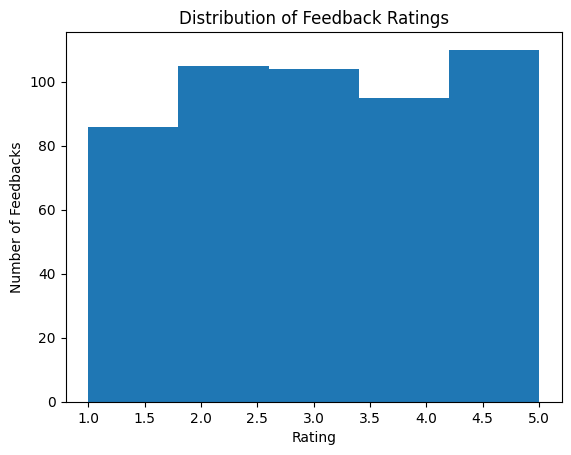

In [7]:
plt.hist(feedback["Rating"], bins=5)
plt.xlabel("Rating")
plt.ylabel("Number of Feedbacks")
plt.title("Distribution of Feedback Ratings")
plt.show()

In [8]:
student_progress["ProgressDate"] = pd.to_datetime(
    student_progress["ProgressDate"]
)

In [12]:
student_progress["Month"] = student_progress["ProgressDate"].dt.to_period("M")
student_progress["Month"]

,Month
0,2024-06
1,2025-01
2,2022-08
3,2024-07
4,2024-06
...,...
9995,2022-02
9996,2023-12
9997,2023-12
9998,2022-02


In [11]:
average_monthly_progress = student_progress.groupby("Month")["ProgressPercent"].mean()
average_monthly_progress

,ProgressPercent
Month,
2022-01,53.490385
2022-02,48.442396
2022-03,50.166667
2022-04,50.205742
2022-05,51.758242
2022-06,49.887755
2022-07,48.850220
2022-08,49.295775
2022-09,52.600000


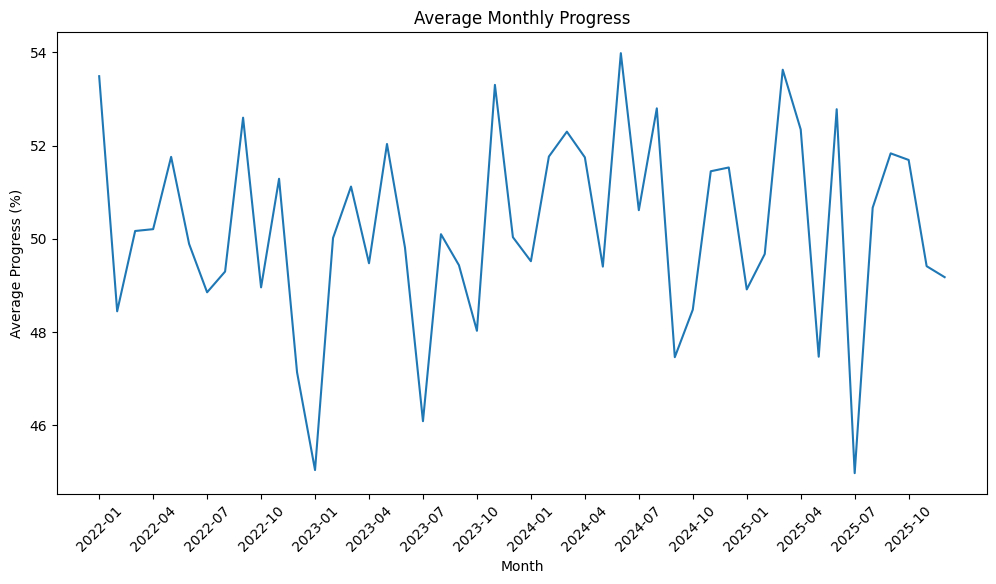

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    average_monthly_progress.index.astype(str),
    average_monthly_progress.values
)

plt.xlabel("Month")
plt.ylabel("Average Progress (%)")
plt.title("Average Monthly Progress")

plt.xticks(
    range(0, len(average_monthly_progress), 3),
    average_monthly_progress.index.astype(str)[::3],
    rotation=45
)

plt.show()

In [ ]:
#Scatter: Course duration vs. rating

In [30]:
course_feedback = pd.read_excel("/content/vw_CourseFeedback.xls")

In [31]:
courses = pd.read_csv("/content/courses.csv")

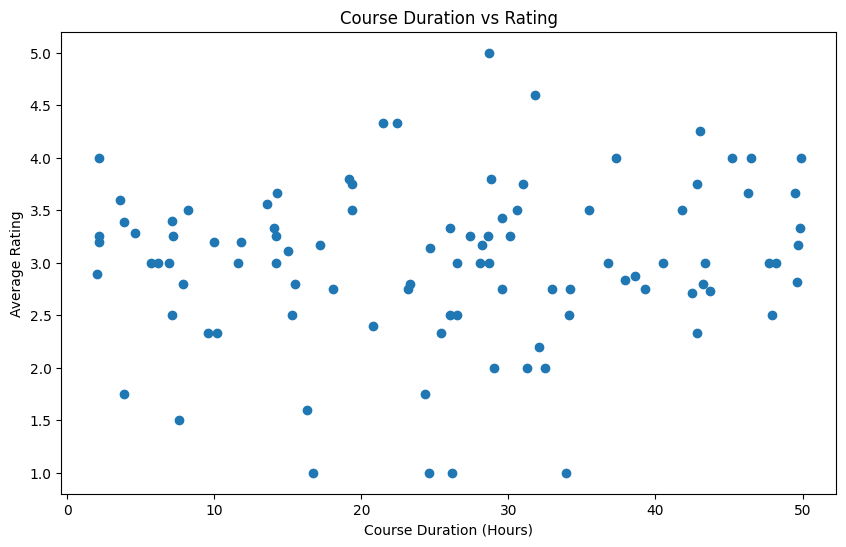

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rating_duration["DurationHrs"],
    rating_duration["avgrating"]
)

plt.xlabel("Course Duration (Hours)")
plt.ylabel("Average Rating")
plt.title("Course Duration vs Rating")

plt.show()